In [1]:
import numpy as np
from IPython.display import Image, display
from sedona.spark import SedonaContext
import itertools
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from sedona.stats.clustering.dbscan import dbscan
import pyspark.sql.functions as f
import math
from sedona.stats.outlier_detection.local_outlier_factor import local_outlier_factor

In [2]:
additional_packages = [
    'org.apache.sedona:sedona-spark-3.5_2.12:1.7.1',
    'org.datasyslab:geotools-wrapper:1.7.1-28.5',
]

bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder().\
     config("spark.jars.packages", ",".join(additional_packages)).\
     getOrCreate()

sedona = SedonaContext.create(config)
sedona.sparkContext.setLogLevel("ERROR")

sedona.sparkContext.setCheckpointDir("checkpoint")

:: loading settings :: url = jar:file:/opt/spark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
org.apache.sedona#sedona-spark-3.5_2.12 added as a dependency
org.datasyslab#geotools-wrapper added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-5b7807c0-e904-40d1-9624-bb0673077b38;1.0
	confs: [default]
	found org.apache.sedona#sedona-spark-3.5_2.12;1.7.1 in central
	found org.apache.sedona#sedona-common;1.7.1 in central
	found org.apache.commons#commons-math3;3.6.1 in central
	found org.locationtech.jts#jts-core;1.20.0 in central
	found org.wololo#jts2geojson;0.16.1 in central
	found org.locationtech.spatial4j#spatial4j;0.8 in central
	found com.google.geometry#s2-geometry;2.0.0 in central
	found com.google.guava#guava;25.1-jre in central
	found com.google.code.findbugs#jsr305;3.0.2 in central
	found org.checkerframework#checker-qual;2.0.0 in central
	found com.google.errorprone#error_prone_annotations;2.1.3 in central
	found com.google.j2objc#j2objc-

# loading denisty points

In [3]:
density_points = pd.read_csv("../source_data/density_points/density_points.csv").reset_index()
density_points_sedona_df = sedona.createDataFrame(density_points).\
    selectExpr("index", "ST_Point(x, y) AS geom")

density_points_sedona_df.createOrReplaceTempView("density")

Text(0.5, 1.0, 'Point Locations')

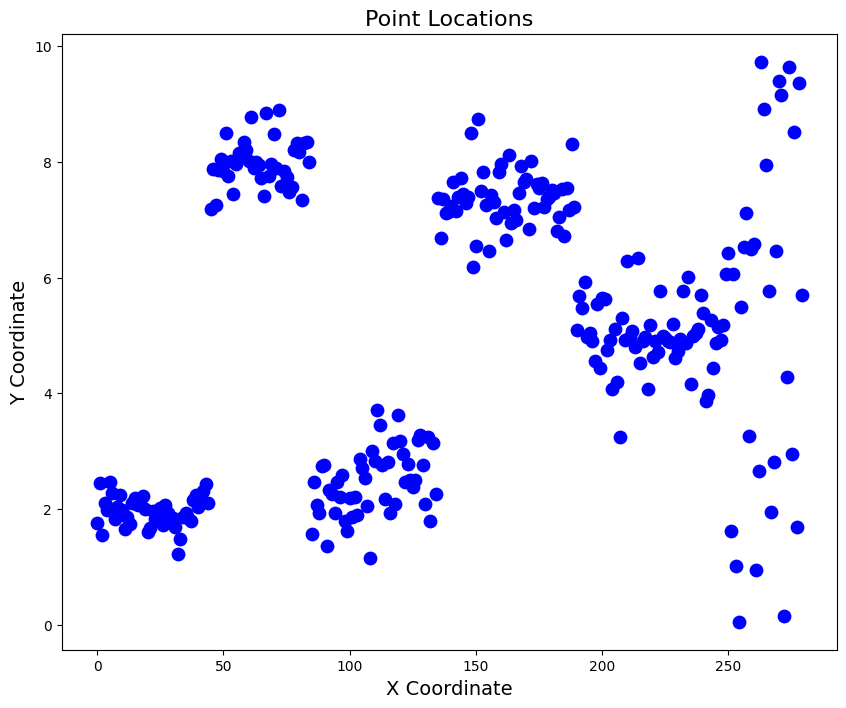

In [4]:
plt.figure(figsize=(10, 8))

plt.scatter(
    np.array(density_points)[:, 0], 
    np.array(density_points)[:, 1],
    s=80, 
    color="blue"
)
plt.xlabel('X Coordinate', fontsize=14)
plt.ylabel('Y Coordinate', fontsize=14)
plt.title('Point Locations', fontsize=16)

In [5]:
## note this example is not optimal, we use this as a explanation to understand the concept of the Local Outlier Detection algorithm

In [6]:
index = 100
k = 5

In [79]:
# find the nearest neigbors of the point
def get_neighbors(point_id, n):
    result = sedona.sql(
        f"""
        WITH selected_point AS (
            SELECT * 
            FROM density 
            WHERE index = {point_id}
        )
        SELECT 
            d.index,
            ST_Distance(s.geom, d.geom) AS distance,
            d.geom as geom,
            s.geom as point_geom
        FROM selected_point AS s, density AS d
        WHERE d.index <> {point_id}
        ORDER BY ST_Distance(s.geom, d.geom) ASC
        LIMIT {n}
        
        """
    )

    rows = [row for row in result.collect()]

    max_distance = max([row["distance"] for row in rows])

    return {
        "point_geom": rows[0]["point_geom"],
        "max_distance": max_distance,
        "index": point_id,
        "neighbors": [[row["index"], row["geom"]] for row in rows]
        
    }

In [80]:
point_index_neighbors = get_neighbors(index, k)

In [81]:
point_index_neighbors

{'point_geom': <POINT (2.192 5.656)>,
 'max_distance': 0.9960758908197521,
 'index': 100,
 'neighbors': [[277, <POINT (1.695 5.568)>],
  [118, <POINT (2.078 6.458)>],
  [126, <POINT (2.504 6.448)>],
  [123, <POINT (2.778 6.409)>],
  [99, <POINT (1.619 6.471)>]]}

In [61]:
## Vizualize the target point and its neighbors

In [82]:
neighbor_ids = [el[0] for el in point_index_neighbors['neighbors']]

viz_data = sedona.sql(
    f"""
    SELECT
        index,
        geom,
        'neighbor' AS type
    FROM density
    where index in {tuple(neighbor_ids)}
    UNION ALL
    SELECT
        index,
        geom,
        'point' AS type
    FROM density
    where index = {index}
    UNION ALL
    SELECT
        index,
        geom,
        'other' AS type
    FROM density
    where index <> {index} AND index not in {tuple(neighbor_ids)}
    """
)

In [83]:
gdf = gpd.GeoDataFrame(viz_data.toPandas(), geometry="geom")

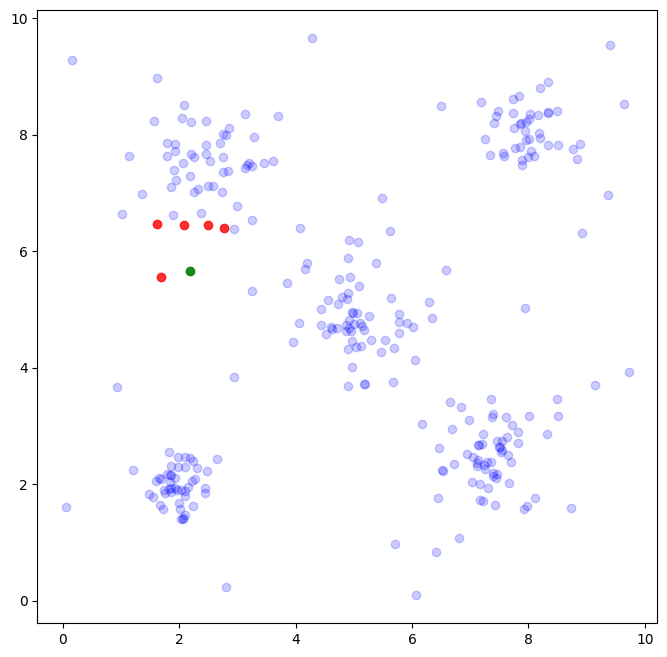

In [84]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

geom_types = {
    "neighbor": ["red", 0.8],
    "point": ["green", 0.9],
    "other": ["blue", 0.2],
}

for geom_type, properties in geom_types.items():
    gdf[gdf["type"] == geom_type].plot(alpha=properties[1], ax=ax, color=properties[0])

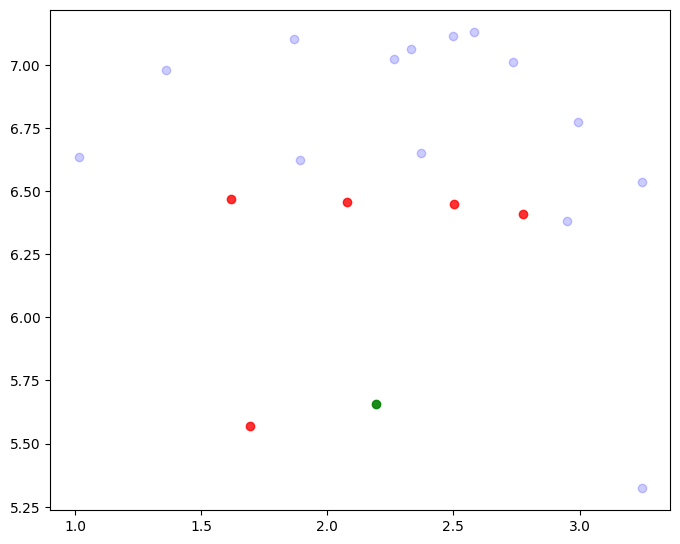

In [85]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

x, y = density_points[density_points["index"] == index][["x", "y"]].values.tolist()[0]

for geom_type, properties in geom_types.items():
    gdf[
        (gdf["type"] == geom_type) &
        (gdf["geom"].centroid.x < x+1.5) &
        (gdf["geom"].centroid.y < y+1.5) &
        (gdf["geom"].centroid.y > y-1.5) &
        (gdf["geom"].centroid.x > x-1.5)
    ].plot(alpha=properties[1], ax=ax, color=properties[0])

In [70]:
## Calculating the lrd

In [128]:
def get_lrd(index, k):
    neighbors = get_neighbors(index, k)
    rsum = 0
    n = 0
    for n_id, neighbor_geom in neighbors["neighbors"]:
        n += 1
        neighbor_k = get_neighbors(n_id, k)
        max_distance = neighbor_k['max_distance']
        max_distance_rounded = round(max_distance, 3)
        distance = neighbor_geom.distance(neighbors['point_geom'])
        distance_rounded = round(distance, 3)
        
        rd = max([distance, max_distance])
        rd_rounded = round(rd, 3)


        print(f"neighbor_id={n_id} max_distance={max_distance_rounded} distance={distance_rounded} rd={rd_rounded}")
        rsum += rd

    return 1/(1e-10 + (rsum/n))

In [129]:
point_lrd = get_lrd(index, k)

neighbor_id=277 max_distance=1.196 distance=0.504 rd=1.196


neighbor_id=118 max_distance=0.595 distance=0.81 rd=0.81


neighbor_id=126 max_distance=0.59 distance=0.852 rd=0.852


neighbor_id=123 max_distance=0.487 distance=0.954 rd=0.954


[Stage 152:=================================================>   (113 + 8) / 121]

neighbor_id=99 max_distance=0.68 distance=0.996 rd=0.996


In [136]:
neighbord_lrds = []
for n in neighbor_ids:
    lrd = get_lrd(n, k)
    print(f"neighbor_id={n} lrd={round(lrd, 3)}")
    neighbord_lrds.append(lrd)

neighbor_id=100 max_distance=0.996 distance=0.504 rd=0.996


neighbor_id=99 max_distance=0.68 distance=0.906 rd=0.906


Exception in thread "serve-DataFrame" java.net.SocketTimeoutException: Accept timed out
	at java.base/sun.nio.ch.NioSocketImpl.timedAccept(NioSocketImpl.java:694)
	at java.base/sun.nio.ch.NioSocketImpl.accept(NioSocketImpl.java:738)
	at java.base/java.net.ServerSocket.implAccept(ServerSocket.java:690)
	at java.base/java.net.ServerSocket.platformImplAccept(ServerSocket.java:655)
	at java.base/java.net.ServerSocket.implAccept(ServerSocket.java:631)
	at java.base/java.net.ServerSocket.implAccept(ServerSocket.java:588)
	at java.base/java.net.ServerSocket.accept(ServerSocket.java:546)
	at org.apache.spark.security.SocketAuthServer$$anon$1.run(SocketAuthServer.scala:65)
                                                                                

neighbor_id=118 max_distance=0.595 distance=0.969 rd=0.969


neighbor_id=103 max_distance=0.543 distance=1.075 rd=1.075


...

neighbor_id=118 max_distance=0.595 distance=0.459 rd=0.595


neighbor_id=91 max_distance=0.64 distance=0.571 rd=0.64


neighbor_id=253 max_distance=1.006 distance=0.626 rd=1.006


[Stage 192:==========================================>          (96 + 11) / 121]

neighbor_id=101 max_distance=0.461 distance=0.68 rd=0.68
neighbor_id=99 lrd=1.444


In [122]:
sum(neighbord_lrds)/(len(neighbord_lrds) * point_lrd)

1.4643711653792912

## Whole dataset

In [9]:
local_outlier_factor(
    density_points_sedona_df,
    5
).\
    show(5, False)

+-----+---------------------------------------------+------------------+
|index|geom                                         |lof               |
+-----+---------------------------------------------+------------------+
|76   |POINT (7.480335462299658 8.404466746884305)  |1.0927074243981525|
|8    |POINT (2.0275282329606505 1.4037293256197323)|1.0191584064861596|
|41   |POINT (2.103085486870538 1.4710879533911798) |1.0371086942776708|
|224  |POINT (4.996987276805067 4.744590013830861)  |0.9561091949623256|
|19   |POINT (1.9959508325786195 1.68268672131323)  |1.2683124973214734|
+-----+---------------------------------------------+------------------+
only showing top 5 rows



In [ ]:
point_index_neighbors

{'point_geom': <POINT (2.192 5.656)>,
 'max_distance': 0.9960758908197521,
 'index': 100,
 'neighbors': [[277, <POINT (1.695 5.568)>],
  [118, <POINT (2.078 6.458)>],
  [126, <POINT (2.504 6.448)>],
  [123, <POINT (2.778 6.409)>],
  [99, <POINT (1.619 6.471)>]]}

In [137]:
0.972+1.736+1.796+1.668+1.444

7.6160000000000005

In [139]:
round(7.616/(5 * 1.04), 3)

1.465